# Muon Selection Integrated Test

이 notebook은 기존 `Number_of_Muon`, `Muon+Displacement`, `Muon+Isolation` study를 하나로 묶어서, charge constraint 대신 `Mu-LJ Mu >= 2`를 사용하는 전략을 검증한다.

주요 결론 후보는 다음과 같다.

- 기존 reference: even muon charge constraint
- optimized number-of-muon cut: `Mu-LJ Mu >= 2`
- final selection candidate: `Mu-LJ Mu >= 2 + displacement`
- isolation은 selection-level cut으로 쓸지, ABCD 변수로 넘길지 cross-check한다.


## 0. Imports and style


In [13]:
# python
import sys
import os
import importlib
from pathlib import Path

import awkward as ak
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
import yaml
from tqdm.notebook import tqdm

from coffea import processor
import coffea.util

sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path:
    sys.path.insert(1, sidm_path)

from sidm.tools import utilities, sidm_processor, scaleout, cutflow
from sidm.tools import llpnanoaodschema

importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)

utilities.set_plot_style()
%matplotlib inline


## 1. Study configuration

기본 benchmark는 cross-cleaning smoke test와 같은 `2Mu2E_500GeV_0p25GeV_2p0mm` signal 하나다. Background는 이번 test notebook에서 제외한다.

- `FULL_SAMPLE=False`: ROOT 3개로 smoke test를 수행하고 `*_smoke3.coffea`로 저장한다.
- `FULL_SAMPLE=True`: 해당 benchmark의 모든 ROOT 파일을 처리하고 `*_full.coffea`로 저장한다.
- `RUN_PROCESSING=False`: processing을 건너뛰고 선택된 mode의 기존 `.coffea` output만 로드한다.


In [14]:
RUN_PROCESSING = True
FULL_SAMPLE = True

PROCESS_2MU2E = True
PROCESS_4MU = True

SMOKE_TEST_FILES = 3
MAX_FILES_SIGNAL = -1 if FULL_SAMPLE else SMOKE_TEST_FILES
OUTPUT_TAG = "full" if FULL_SAMPLE else f"smoke{SMOKE_TEST_FILES}"

OUTPUT_DIR = Path("coffea_outputs_muon_selection_integrated")
FIGURE_DIR = Path("figures_muon_selection_integrated")
SAVE_FIGURES = False
PLOT_LINEWIDTH = 2.5

OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(exist_ok=True)

print(f"Processing mode: {OUTPUT_TAG} (max_files={MAX_FILES_SIGNAL})")


Processing mode: full (max_files=-1)


In [15]:
channels_number = [
    "baseNoLj_No_Muon_Constraint",
    "baseNoLj_Even_Muon_Charge",
    "baseNoLj_Only_One_Muon",
    "baseNoLj_Only_Two_Muon",
    "baseNoLj_Only_Three_Muon",
    "baseNoLj_Four_Ormore_Muon",
]

channels_displacement = [
    "baseNoLj_No_Muon_Constraint",
    "baseNoLj_Even_Muon_Charge",
    "baseNoLj_Two_Ormore_Muon",
    "baseNoLj_Even_Muon_Charge_Displacement",
    "baseNoLj_Two_Ormore_Muon_Displacement",
]

channels_isolation = [
    "baseNoLj_No_Muon_Constraint",
    "baseNoLj_Two_Ormore_Muon",
    "baseNoLj_Two_Ormore_Muon_Displacement",
    "baseNoLj_Two_Ormore_Muon_Displacement_EgmIso_MuIso",
]

channels_final_compare = channels_isolation.copy()

channels_all = list(dict.fromkeys(
    channels_number + channels_displacement + channels_isolation + channels_final_compare
))

channel_labels = {
    "baseNoLj_No_Muon_Constraint": "Baseline",
    "baseNoLj_Even_Muon_Charge": "Even charge",
    "baseNoLj_Only_One_Muon": "Mu == 1",
    "baseNoLj_Only_Two_Muon": "Mu == 2",
    "baseNoLj_Only_Three_Muon": "Mu == 3",
    "baseNoLj_Four_Ormore_Muon": "Mu >= 4",
    "baseNoLj_Two_Ormore_Muon": "Mu >= 2",
    "baseNoLj_Even_Muon_Charge_Displacement": "Even charge + displacement cut",
    "baseNoLj_Two_Ormore_Muon_Displacement": "Mu >= 2 + displacement cut",
    "baseNoLj_Two_Ormore_Muon_Displacement_EgmIso_MuIso": (
        "Mu >= 2 + displacement + both iso cut"
    ),
}


In [16]:
signal_2mu2e_benchmark = [
    "2Mu2E_500GeV_0p25GeV_2p0mm",
]

# Same benchmark point used in cross-cleaning; keep disabled for the first smoke test.
signal_4mu_benchmark = [
    "4Mu_500GeV_0p25GeV_2p0mm",
] if PROCESS_4MU else []

plot_signal_samples = signal_2mu2e_benchmark + signal_4mu_benchmark


## 2. Processing

Signal에는 `genA_muLj_ptRatio`, Mu-LJ/EGM-LJ kinematics, displacement, mass histogram을 포함한다. 현재 `Muon_selection_base` collection은 `mu_lj_isolation` 이름 문제로 사용하지 않는다.


In [17]:
runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    # executor=processor.DaskExecutor(client=client),
    schema=llpnanoaodschema.LLPNanoAODSchema,
    skipbadfiles=True,
)

processor_signal = sidm_processor.SidmProcessor(
    channels_all,
    ["mu_lj_base", "egm_lj_base", "lj_displacement", "genA_ratio"],
    unweighted_hist=False,
)


In [18]:
def output_name(signal_kind):
    return f"signal_{signal_kind}_integrated_{OUTPUT_TAG}"


def output_path(name):
    return OUTPUT_DIR / f"{name}.coffea"


def run_signal_group(sample_names, location_cfg, out_name, max_files=-1):
    fileset = utilities.make_fileset(
        sample_names,
        "llpNanoAOD_v2",
        max_files=max_files,
        location_cfg=location_cfg,
    )
    n_files = sum(len(sample_files["files"]) for sample_files in fileset.values())
    print(f"Processing {len(fileset)} sample(s) with {n_files} ROOT file(s)")

    output = runner.run(fileset, treename="Events", processor_instance=processor_signal)
    save_path = output_path(out_name)
    coffea.util.save(output, save_path)
    print(f"Saved {save_path}")
    return output


In [ ]:
if RUN_PROCESSING:
    if PROCESS_2MU2E:
        output_2mu2e = run_signal_group(
            signal_2mu2e_benchmark,
            "signal_2mu2e_v10.yaml",
            output_name("2mu2e"),
            max_files=MAX_FILES_SIGNAL,
        )

    if PROCESS_4MU and signal_4mu_benchmark:
        output_4mu = run_signal_group(
            signal_4mu_benchmark,
            "signal_4mu_v10.yaml",
            output_name("4mu"),
            max_files=MAX_FILES_SIGNAL,
        )


## 3. Load processed outputs

Processing 직후든 kernel을 새로 열었든, 현재 `FULL_SAMPLE` mode에 대응하는 `.coffea` 파일을 아래 셀에서 로드한다. 이후 notebook에서는 `out[sample]` 형태로 통일해서 사용한다.


In [19]:
def load_coffea_output(coffea_file):
    coffea_file = Path(coffea_file)
    if not coffea_file.exists():
        raise FileNotFoundError(
            f"Missing {coffea_file}; set RUN_PROCESSING=True to create it first."
        )

    loaded = coffea.util.load(coffea_file)
    if "out" not in loaded:
        raise KeyError(f"{coffea_file} does not contain key out")
    print(f"Loaded {coffea_file}")
    return loaded["out"]


def merge_coffea_output(out, coffea_file):
    for sample, sample_out in load_coffea_output(coffea_file).items():
        out[sample] = sample_out


out = {}

signal_output_files = [output_name("2mu2e")]
if PROCESS_4MU:
    signal_output_files.append(output_name("4mu"))

for name in signal_output_files:
    merge_coffea_output(out, output_path(name))

print(f"Loaded {len(out)} samples")
print(sorted(out.keys()))


Loaded coffea_outputs_muon_selection_integrated/signal_2mu2e_integrated_full.coffea
Loaded coffea_outputs_muon_selection_integrated/signal_4mu_integrated_full.coffea
Loaded 2 samples
['2Mu2E_500GeV_0p25GeV_2p0mm', '4Mu_500GeV_0p25GeV_2p0mm']


## 4. Plot helpers


In [20]:
def available_samples(samples):
    return [sample for sample in samples if sample in out]


def require_samples(samples):
    missing = [sample for sample in samples if sample not in out]
    if missing:
        raise KeyError(f"Missing samples: {missing}")
    return samples


def save_figure(fig, name):
    if fig is None:
        return
    if SAVE_FIGURES:
        path = FIGURE_DIR / name
        fig.savefig(path, bbox_inches="tight")
        print(f"Saved {path}")


def channel_legend(channels):
    return [channel_labels.get(channel, channel) for channel in channels]


def rebin_for_plot(hist_obj, target_bins=25):
    return utilities.auto_rebin_hist(
        hist_obj,
        target_bins=target_bins,
        rebin_threshold=target_bins,
    )


def get_hist(sample, hist_name, channel, hist_range=slice(None)):
    return out[sample]["hists"][hist_name][channel, hist_range]


def sum_hists(samples, hist_name, channel, hist_range=slice(None)):
    hist_sum = None
    for sample in samples:
        if sample not in out:
            continue
        hist_obj = get_hist(sample, hist_name, channel, hist_range)
        if hist_sum is None:
            hist_sum = hist_obj.copy()
        else:
            hist_sum += hist_obj
    return hist_sum


def draw_ratio_plot(nums, den, labels, text="", ax=None, rax=None, eff_ylim=(0, 1.2)):
    if len(labels) != len(nums) + 1:
        raise ValueError("labels must contain one entry for the denominator and each numerator")

    if ax is None or rax is None:
        fig, (ax, rax) = plt.subplots(
            2,
            1,
            figsize=(20, 15),
            sharex=True,
            gridspec_kw={"height_ratios": [3, 1], "hspace": 0},
        )
    else:
        fig = ax.figure

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    hep.histplot(den, ax=ax, flow="none", histtype="step", color="black", linewidth=PLOT_LINEWIDTH, label=labels[0])

    for idx, (num, label) in enumerate(zip(nums, labels[1:])):
        color = colors[idx % len(colors)]
        hep.histplot(num, ax=ax, flow="none", histtype="step", color=color, linewidth=PLOT_LINEWIDTH, label=label)
        eff, errors = utilities.get_eff_hist(num, den)
        hep.histplot(
            eff,
            ax=rax,
            histtype="errorbar",
            yerr=errors,
            color=color,
            label=label,
        )

    ax.set_ylabel("Arbitrary Units")
    ax.legend(title=text, alignment="left")
    rax.set_ylabel("Efficiency")
    rax.set_ylim(*eff_ylim)
    hep.cms.label(ax=ax)
    return fig


def plot_ratio_wrapper(sample_name, hist_name, channels, hist_range=slice(None), text=""):
    hists = out[sample_name]["hists"][hist_name]
    den = rebin_for_plot(hists[channels[0], hist_range])
    nums = [rebin_for_plot(hists[channel, hist_range]) for channel in channels[1:]]
    fig = draw_ratio_plot(
        nums,
        den,
        labels=channel_legend(channels),
        text=text,
    )
    fig.tight_layout()
    return fig


def plot_ratio_panels(samples, hist_name, channels, hist_range=slice(None), ncols=3, eff_ylim=(0, 1.2)):
    samples = available_samples(samples)
    n_panels = len(samples)
    if n_panels == 0:
        print(f"Skip {hist_name}: no available samples")
        return None

    ncols = min(ncols, n_panels)
    n_sample_rows = int(np.ceil(n_panels / ncols))
    nrows = 2 * n_sample_rows

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(16 * ncols, 8 * nrows),
        sharex="col",
        gridspec_kw={"height_ratios": [3, 1] * n_sample_rows},
    )
    axes = np.asarray(axes).reshape(nrows, ncols)

    for idx, sample in enumerate(samples):
        row = 2 * (idx // ncols)
        col = idx % ncols
        ax = axes[row, col]
        rax = axes[row + 1, col]

        hists = out[sample]["hists"][hist_name]
        den = rebin_for_plot(hists[channels[0], hist_range])
        nums = [rebin_for_plot(hists[channel, hist_range]) for channel in channels[1:]]

        draw_ratio_plot(
            nums,
            den,
            labels=channel_legend(channels),
            text=sample,
            ax=ax,
            rax=rax,
            eff_ylim=eff_ylim,
        )

    for idx in range(n_panels, n_sample_rows * ncols):
        row = 2 * (idx // ncols)
        col = idx % ncols
        axes[row, col].axis("off")
        axes[row + 1, col].axis("off")

    plt.tight_layout()
    return fig


In [21]:
def cutflow_yield(sample, channel, unweighted=False):
    cut_names, yields = utilities.extract_cutflow_yields(
        out[sample]["cutflow"][channel],
        unweighted=unweighted,
        cumulative=True,
    )
    return cut_names[-1], float(yields[-1])


def signal_yield_table(signal_samples, channels, unweighted=False):
    rows = []
    for channel in channels:
        for signal in available_samples(signal_samples):
            final_cut, value = cutflow_yield(signal, channel, unweighted=unweighted)
            rows.append({
                "channel": channel,
                "label": channel_labels.get(channel, channel),
                "sample": signal,
                "final_cut": final_cut,
                "yield": value,
            })
    return pd.DataFrame(rows)


/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:163: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:169: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:163: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:169: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

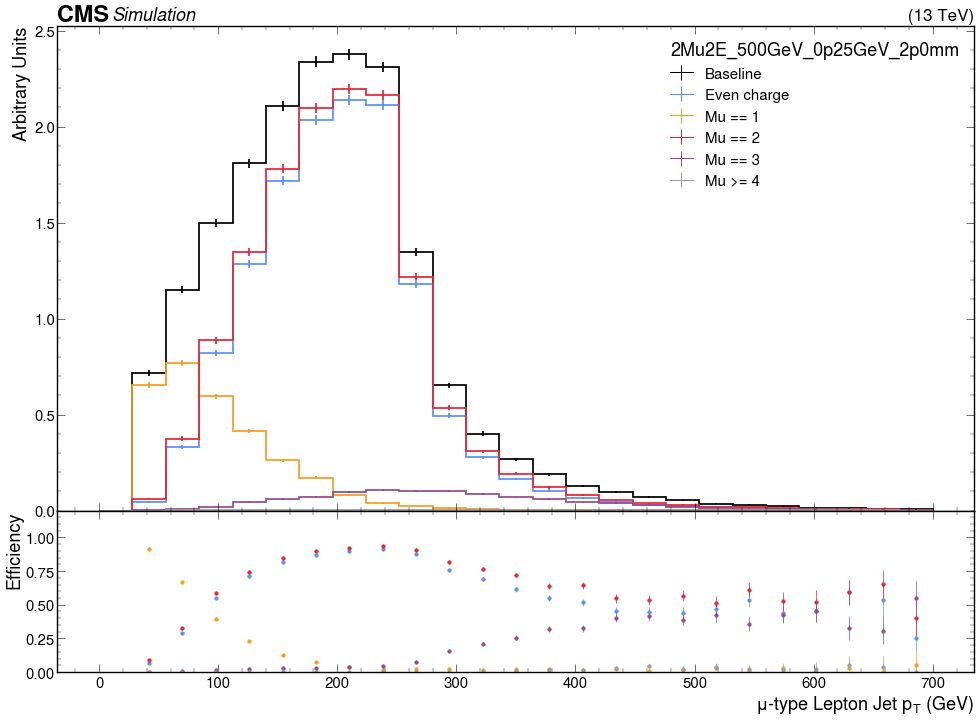

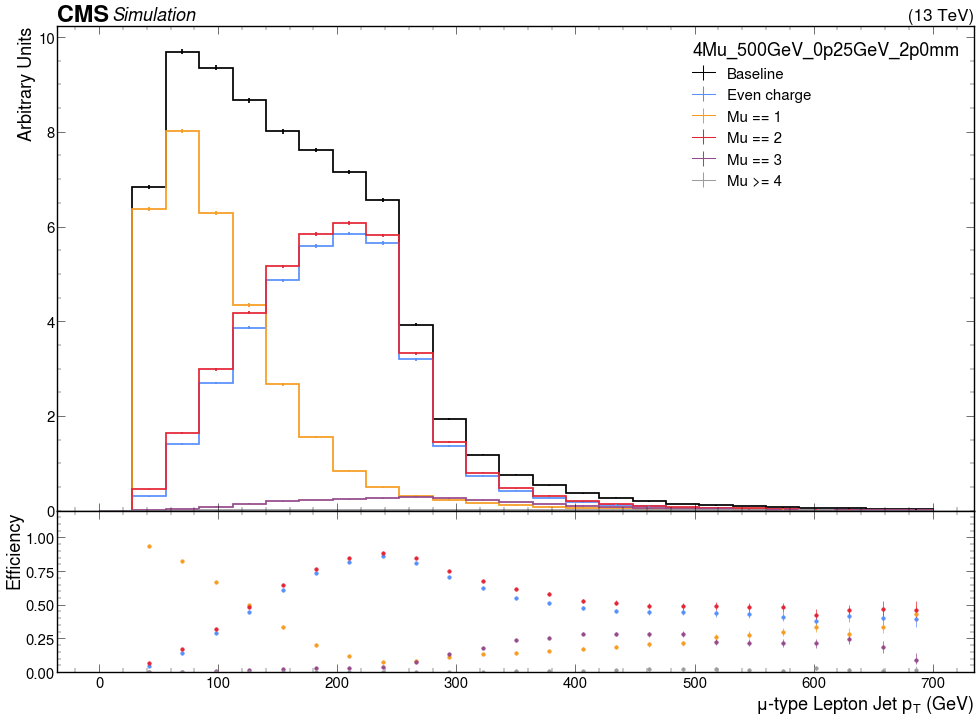

In [22]:
for sample in available_samples(plot_signal_samples):
    fig = plot_ratio_wrapper(
        sample,
        hist_name="mu_lj_pt",
        channels=channels_number,
        hist_range=slice(None, None),
        text=sample,
    )
    save_figure(fig, f"number_muon_mu_lj_pt_{sample}.pdf")


/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:163: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:169: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:163: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:169: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

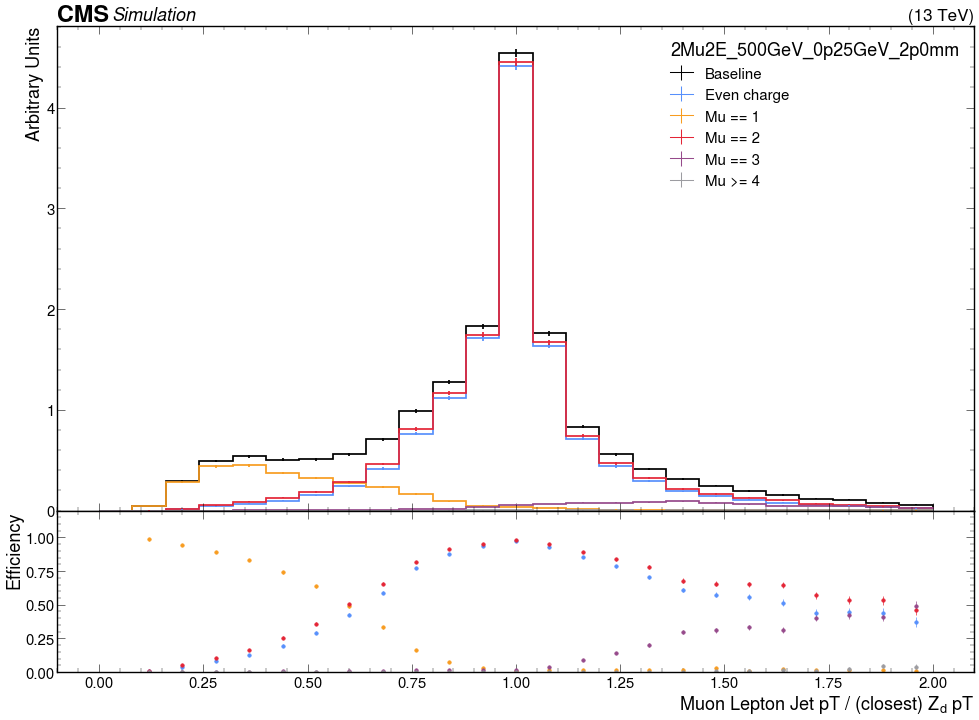

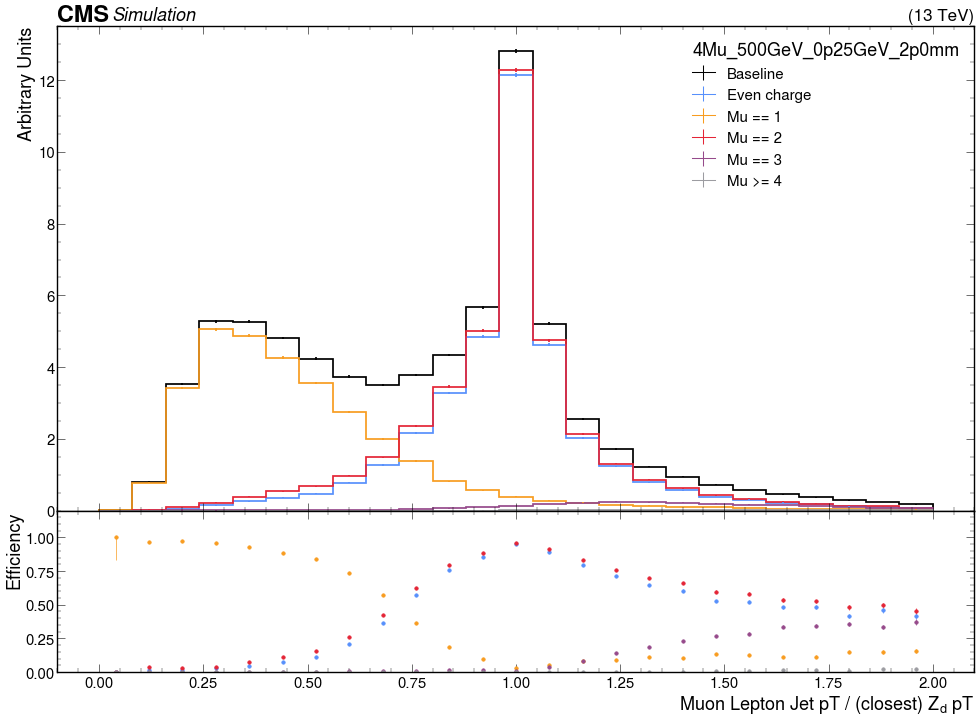

In [23]:
for sample in available_samples(plot_signal_samples):
    fig = plot_ratio_wrapper(
        sample,
        hist_name="genA_muLj_ptRatio",
        channels=channels_number,
        hist_range=slice(None, None),
        text=sample,
    )
    save_figure(fig, f"number_muon_genA_muLj_ptratio_{sample}.pdf")


/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:163: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:169: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:163: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:169: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

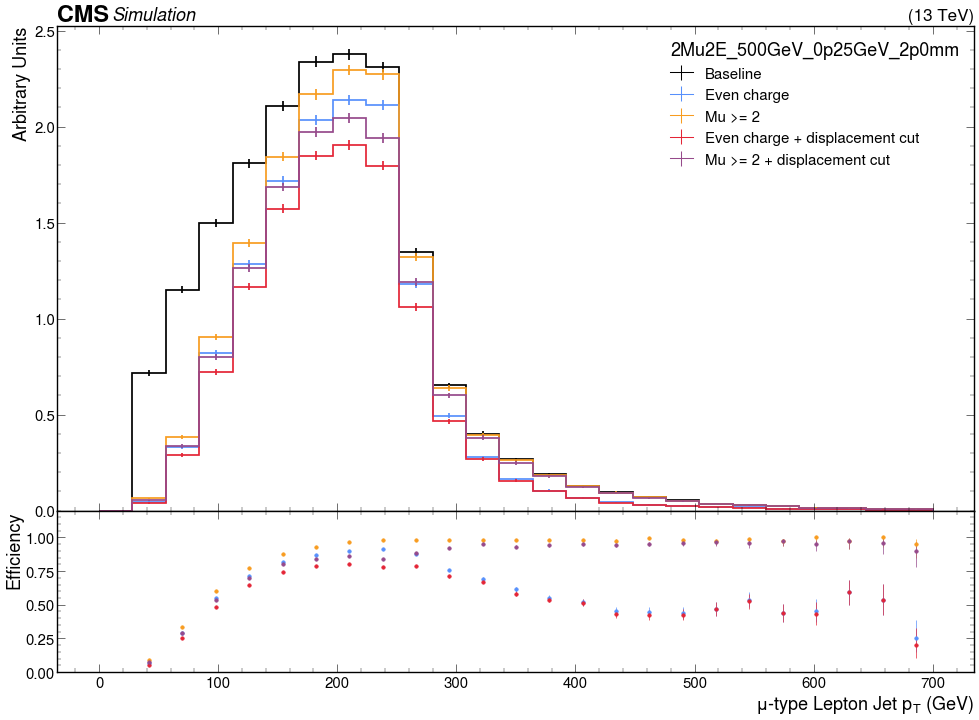

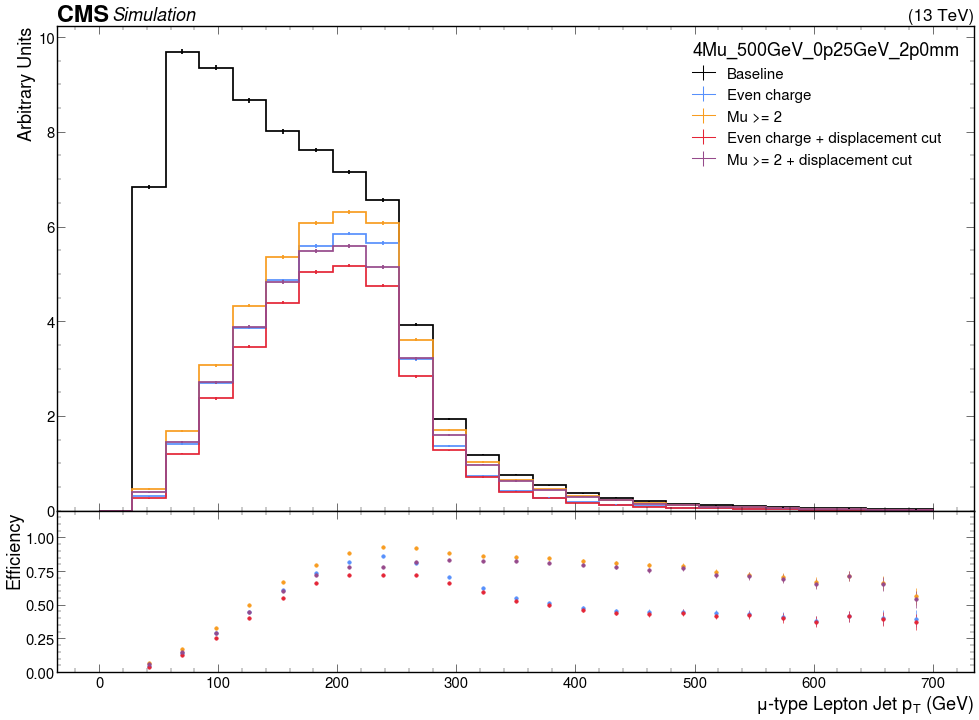

In [24]:
for sample in available_samples(plot_signal_samples):
    fig = plot_ratio_wrapper(
        sample,
        hist_name="mu_lj_pt",
        channels=channels_displacement,
        hist_range=slice(None, None),
        text=sample,
    )
    save_figure(fig, f"displacement_mu_lj_pt_{sample}.pdf")


/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:163: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.varianc

ValueError: Found numerator larger than denominator while calculating binomial uncertainty

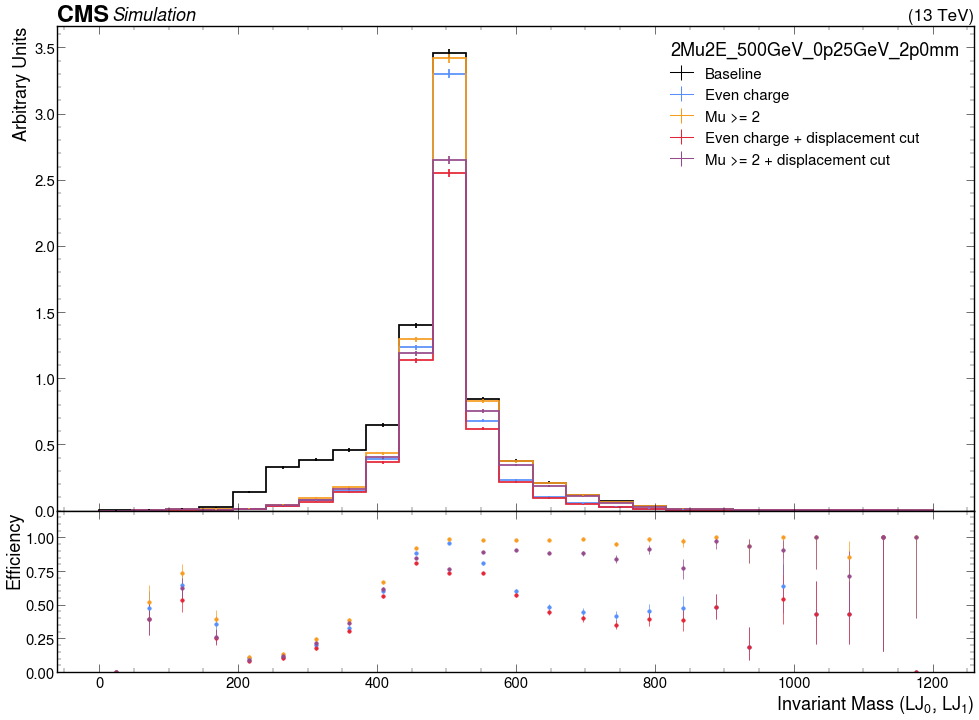

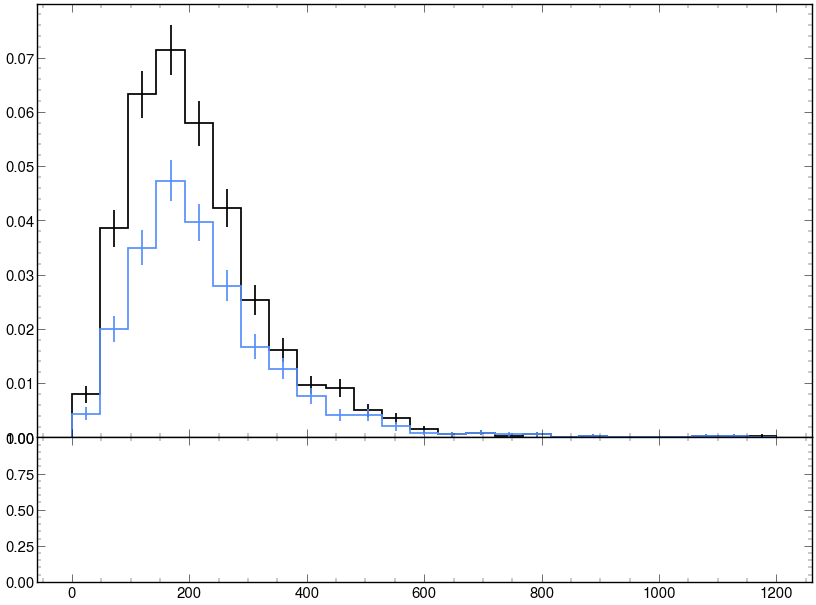

In [26]:
for sample in available_samples(plot_signal_samples):
    fig = plot_ratio_wrapper(
        sample,
        hist_name="mulj_egmlj_invmass",
        channels=channels_displacement,
        hist_range=slice(None, None),
        text=sample,
    )
    save_figure(fig, f"displacement_mass_{sample}.pdf")

/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:163: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:169: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:163: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:169: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

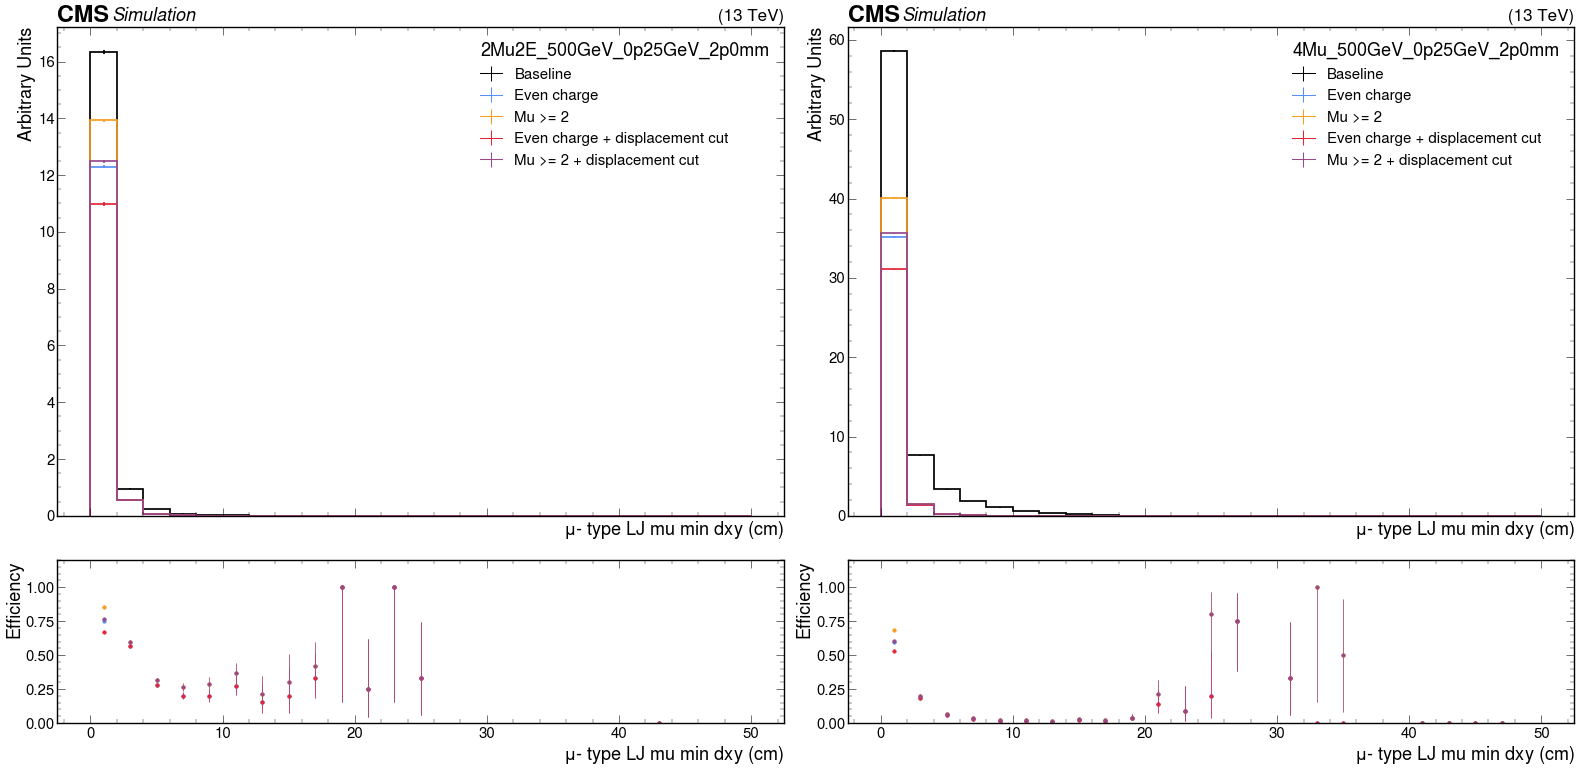

In [27]:
fig = plot_ratio_panels(
    plot_signal_samples,
    hist_name="mu_lj_muon_min_dxy",
    channels=channels_displacement,
    hist_range=slice(None, None),
    ncols=3,
)
save_figure(fig, "mu_lj_min_dxy_even_charge_vs_mu_ge2.pdf")


/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:163: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:169: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:163: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:169: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

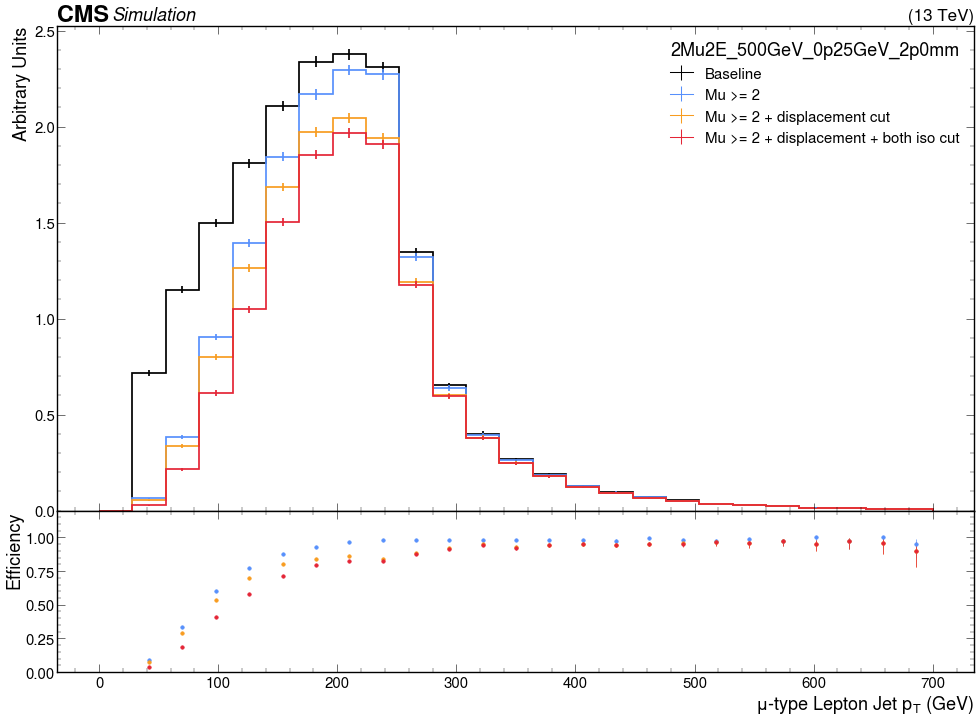

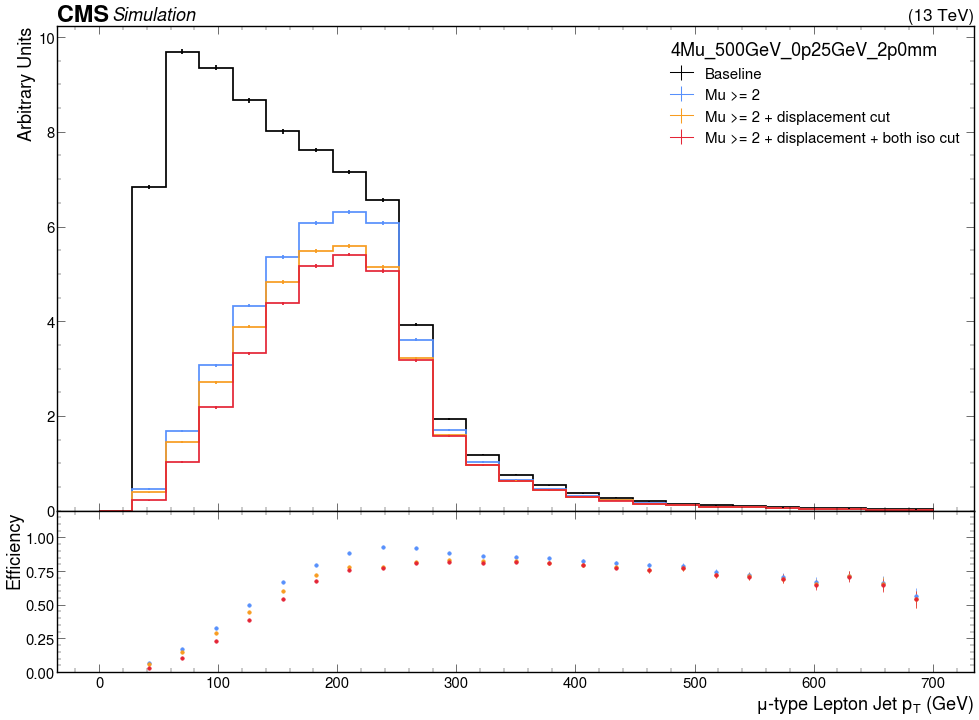

In [28]:
for sample in available_samples(plot_signal_samples):
    fig = plot_ratio_wrapper(
        sample,
        hist_name="mu_lj_pt",
        channels=channels_isolation,
        hist_range=slice(None, None),
        text=sample,
    )
    save_figure(fig, f"isolation_mu_lj_pt_{sample}.pdf")


/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:163: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:169: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:163: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:169: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

ValueError: Found numerator larger than denominator while calculating binomial uncertainty

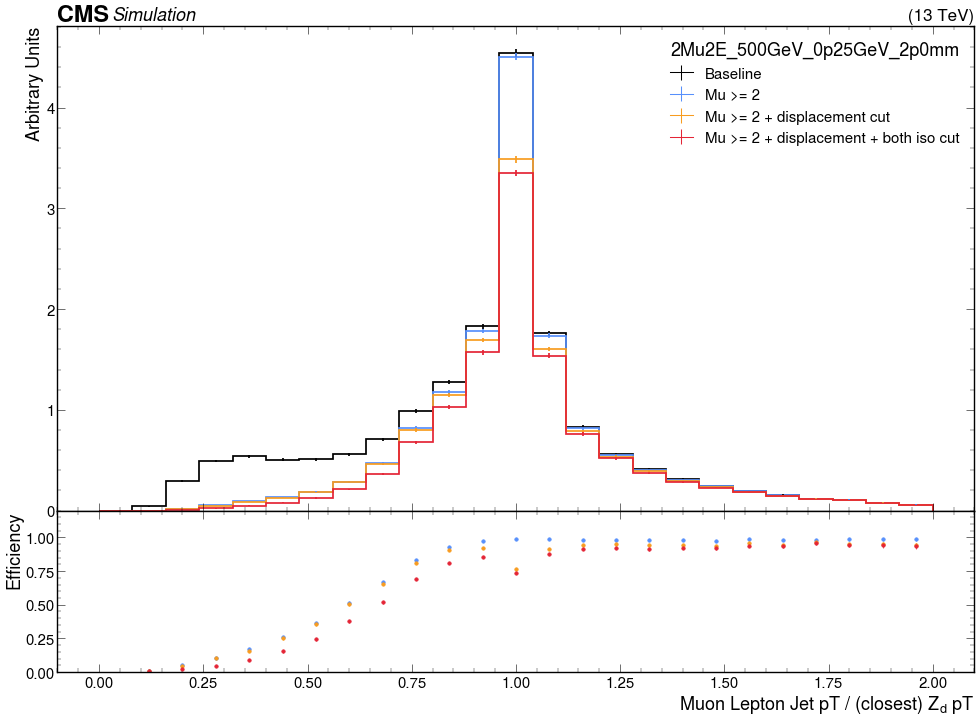

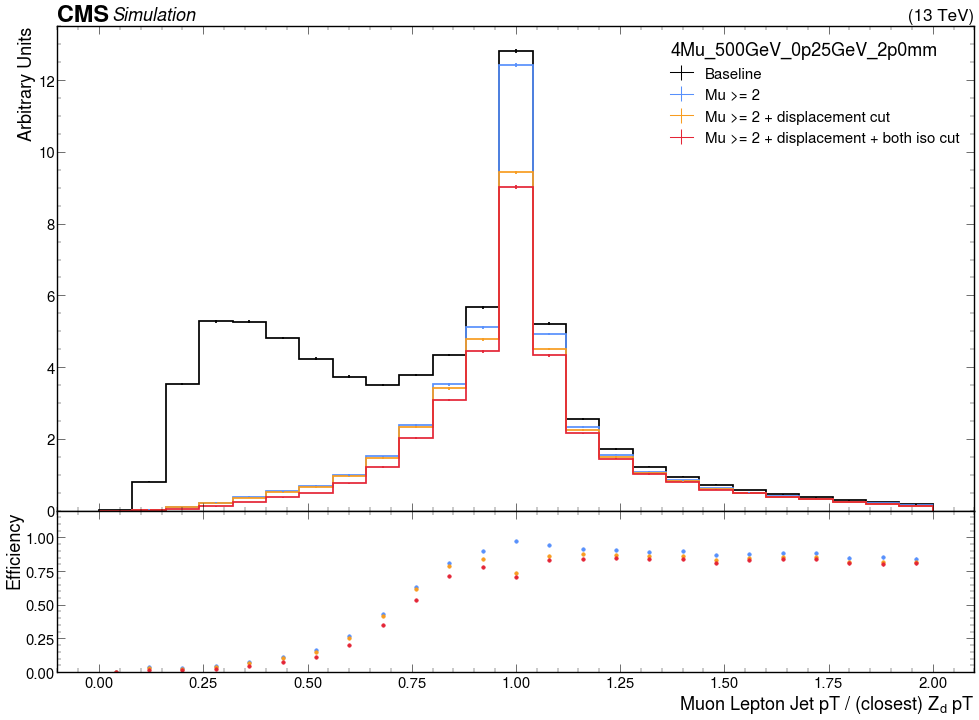

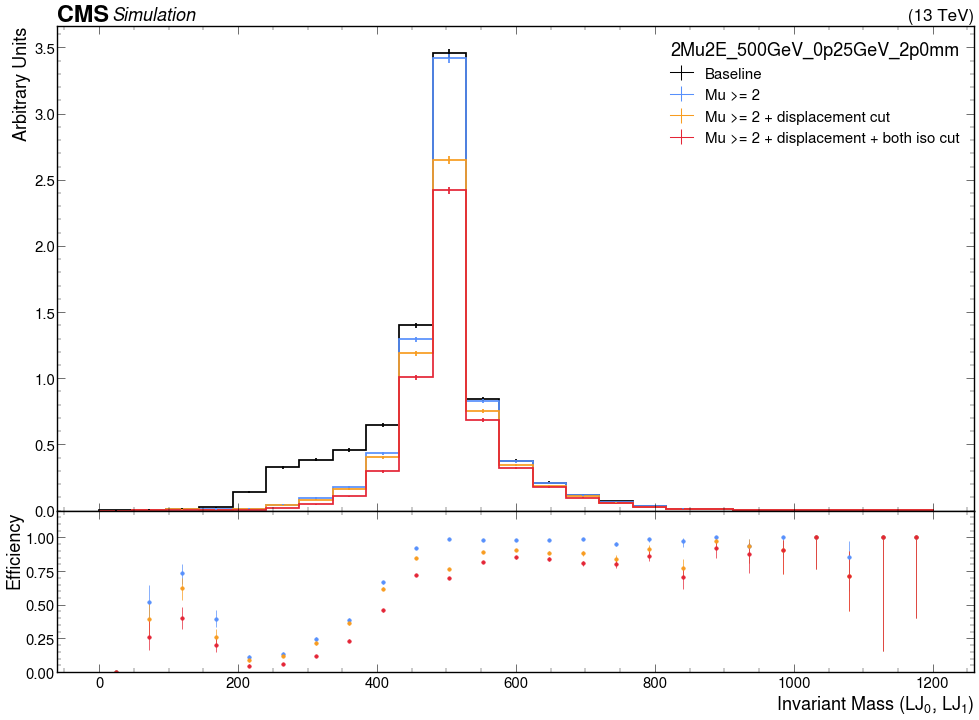

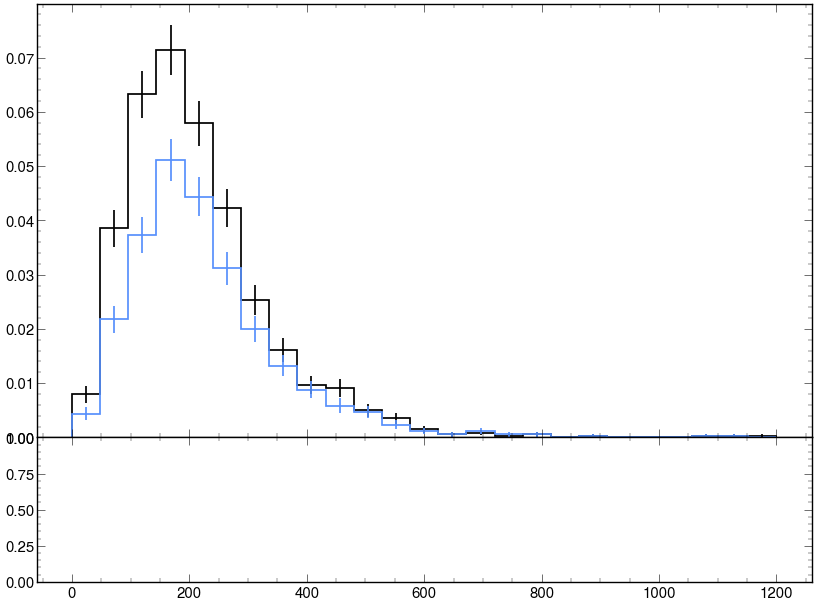

In [29]:
isolation_histograms = [
    ("genA_muLj_ptRatio", "isolation_genA_muLj_ptratio"),
    ("mulj_egmlj_invmass", "isolation_mass"),
]

for hist_name, output_stub in isolation_histograms:
    for sample in available_samples(plot_signal_samples):
        fig = plot_ratio_wrapper(
            sample,
            hist_name=hist_name,
            channels=channels_isolation,
            hist_range=slice(None, None),
            text=sample,
        )
        save_figure(fig, f"{output_stub}_{sample}.pdf")


/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()


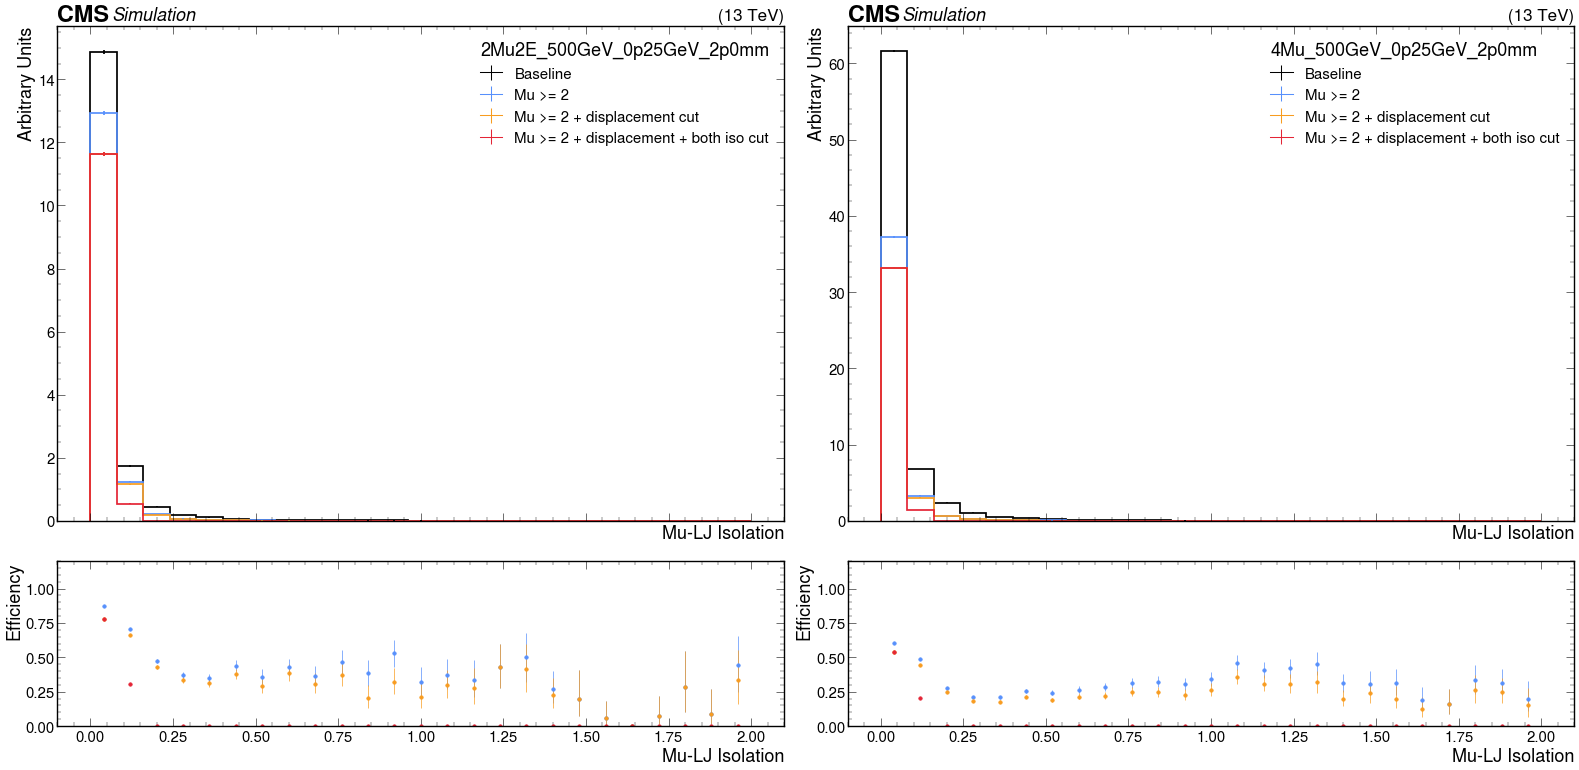

In [30]:
fig = plot_ratio_panels(
    plot_signal_samples,
    hist_name="mu_lj_iso",
    channels=channels_isolation,
    hist_range=slice(None, None),
    ncols=3,
)
save_figure(fig, "mu_lj_iso_mu_ge2_selections.pdf")


/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:163: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:169: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:163: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:169: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances(

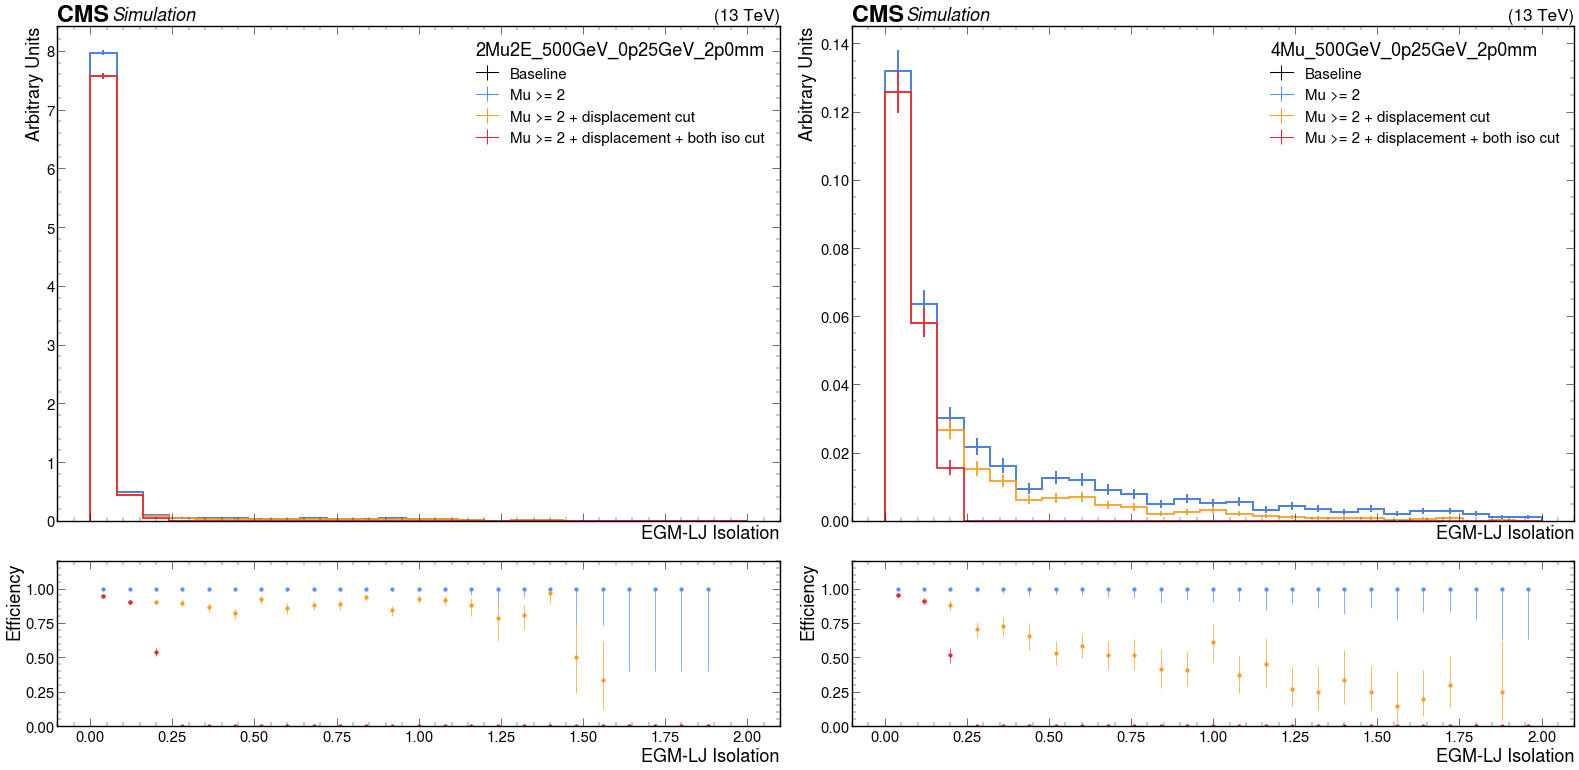

In [31]:
fig = plot_ratio_panels(
    plot_signal_samples,
    hist_name="egm_lj_iso",
    channels=channels_isolation,
    hist_range=slice(None, None),
    ncols=3,
)
save_figure(fig, "egm_lj_iso_mu_ge2_selections.pdf")


## 9. Final mass-shape plot for note

Baseline을 denominator로 두고 `Mu >= 2`, `Mu >= 2 + displacement`, `Mu >= 2 + displacement + both isolation`을 한 plot에서 비교한다.


/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:163: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:168: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/workspace/CMS-SIDM-PR/sidm/tools/utilities.py:169: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.v

ValueError: Found numerator larger than denominator while calculating binomial uncertainty

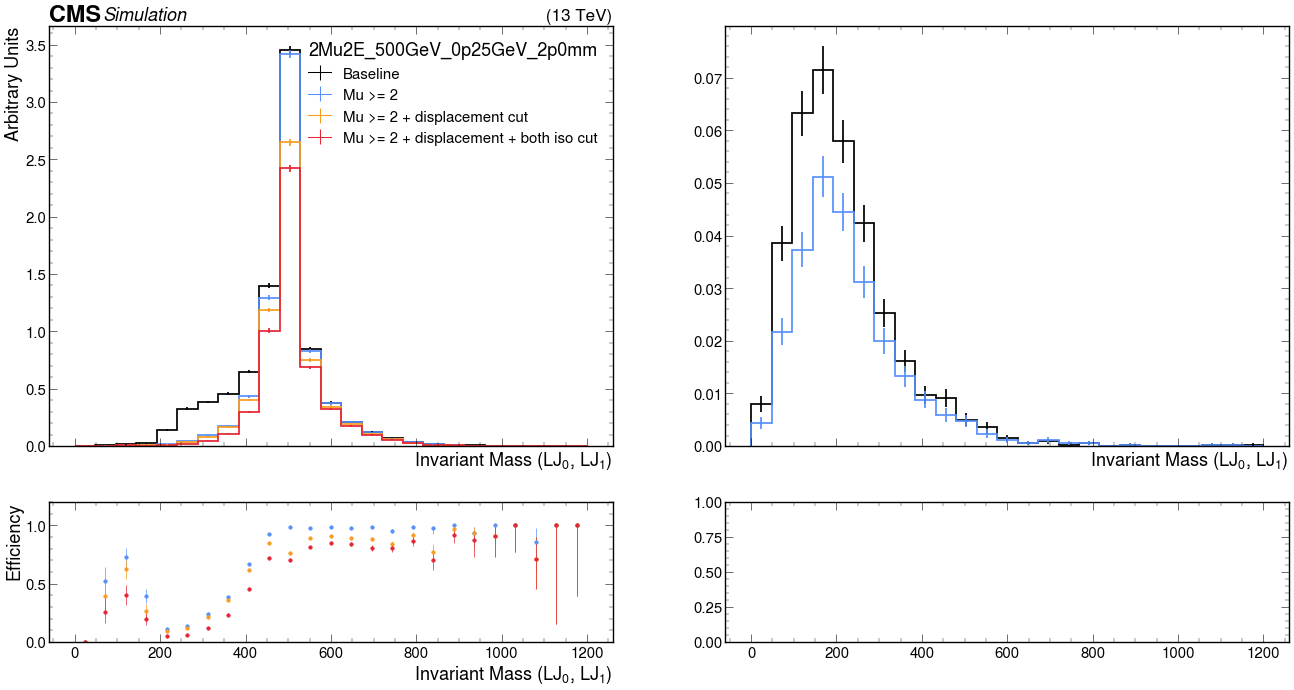

In [32]:
fig = plot_ratio_panels(
    plot_signal_samples,
    hist_name="mulj_egmlj_invmass",
    channels=channels_final_compare,
    hist_range=slice(None, None),
    ncols=3,
)
save_figure(fig, "final_mass_shape_mu_ge2_selections_vs_baseline.pdf")


## 10. Analysis note bullets

이 셀은 plot을 본 뒤 note 문장으로 옮기기 위한 working summary이다. 숫자와 그림 번호는 실행 결과를 보고 채운다.

- Charge constraint는 final-state topology를 간접적으로 요구한다.
- `Mu-LJ Mu >= 2`는 muonic LJ topology를 직접 요구하며, `Mu == 2`보다 signal 통계를 더 보존하는지 확인한다.
- Displacement cut은 prompt-like signal point에서 efficiency loss가 생길 수 있으므로 lifetime별 확장이 필요하다.
- Isolation cut은 추가 signal efficiency loss를 만들 수 있으므로, selection-level cut 대신 ABCD 변수 후보로 남기는 방향을 우선 검토한다.
- 현재 signal-only smoke test의 working selection은 `Mu-LJ Mu >= 2 + displacement`이다.
